# LSTM Pipeline

In [23]:
import os, json, re, time, random, math
from pathlib import Path
from concurrent.futures import ThreadPoolExecutor, as_completed

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import InceptionV3
from tensorflow.keras.applications.inception_v3 import preprocess_input
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.preprocessing.sequence import pad_sequences

try:
    import nltk
    from nltk.translate.bleu_score import corpus_bleu, sentence_bleu, SmoothingFunction
    from nltk.translate.meteor_score import meteor_score
    HAS_NLTK = True
except Exception:
    HAS_NLTK = False

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print('TensorFlow:', tf.__version__)
print('GPU devices:', tf.config.list_physical_devices('GPU'))

TensorFlow: 2.21.0
GPU devices: []


## 1. Set path dataset

In [24]:
BASE_DIR = Path('../../')
DATASET_DIR = BASE_DIR / 'data' / 'rnn & lstm'

IMAGE_DIR = DATASET_DIR / 'Images'
CAPTION_FILE = DATASET_DIR / 'captions.txt'

print('IMAGE_DIR   :', IMAGE_DIR.resolve())
print('CAPTION_FILE:', CAPTION_FILE.resolve())

assert IMAGE_DIR.exists(), f'Folder Images tidak ditemukan: {IMAGE_DIR}'
assert CAPTION_FILE.exists(), f'captions.txt tidak ditemukan: {CAPTION_FILE}'

ARTIFACT_DIR = Path('artifacts_lstm')
FEATURE_DIR = ARTIFACT_DIR / 'features'
MODEL_DIR = ARTIFACT_DIR / 'models'
RESULT_DIR = ARTIFACT_DIR / 'results'

for d in [ARTIFACT_DIR, FEATURE_DIR, MODEL_DIR, RESULT_DIR]:
    d.mkdir(parents=True, exist_ok=True)

IMAGE_DIR   : C:\Users\Anella Utari\Documents\GitHub\Tubes2_IF3270_Kelompok9\data\rnn & lstm\Images
CAPTION_FILE: C:\Users\Anella Utari\Documents\GitHub\Tubes2_IF3270_Kelompok9\data\rnn & lstm\captions.txt


## 2. Load dan cek `captions.txt`

In [25]:
captions_df = pd.read_csv(CAPTION_FILE)
captions_df.columns = [c.strip().lower() for c in captions_df.columns]

print(captions_df.head())
print(captions_df.shape)
print(captions_df.columns)

assert 'image' in captions_df.columns and 'caption' in captions_df.columns

captions_df['image'] = captions_df['image'].astype(str).str.strip()
captions_df['caption'] = captions_df['caption'].astype(str).str.strip()

existing_images = {p.name for p in IMAGE_DIR.iterdir() if p.is_file()}
captions_df = captions_df[captions_df['image'].isin(existing_images)].reset_index(drop=True)

print('Jumlah row caption valid:', len(captions_df))
print('Jumlah image unik valid:', captions_df['image'].nunique())

                       image  \
0  1000268201_693b08cb0e.jpg   
1  1000268201_693b08cb0e.jpg   
2  1000268201_693b08cb0e.jpg   
3  1000268201_693b08cb0e.jpg   
4  1000268201_693b08cb0e.jpg   

                                             caption  
0  A child in a pink dress is climbing up a set o...  
1              A girl going into a wooden building .  
2   A little girl climbing into a wooden playhouse .  
3  A little girl climbing the stairs to her playh...  
4  A little girl in a pink dress going into a woo...  
(40455, 2)
Index(['image', 'caption'], dtype='object')
Jumlah row caption valid: 40455
Jumlah image unik valid: 8091


## 3. Split image 6000 / 1000 / 1000

In [26]:
unique_images = sorted(captions_df['image'].unique())
random.Random(SEED).shuffle(unique_images)

train_imgs = set(unique_images[:6000])
val_imgs = set(unique_images[6000:7000])
test_imgs = set(unique_images[7000:8000])

print('Split image:', len(train_imgs), len(val_imgs), len(test_imgs))

train_df = captions_df[captions_df['image'].isin(train_imgs)].reset_index(drop=True)
val_df = captions_df[captions_df['image'].isin(val_imgs)].reset_index(drop=True)
test_df = captions_df[captions_df['image'].isin(test_imgs)].reset_index(drop=True)

print('Split caption rows:', len(train_df), len(val_df), len(test_df))

Split image: 6000 1000 1000
Split caption rows: 30000 5000 5000


## 4. Preprocessing caption dan vocabulary

In [27]:
PAD_TOKEN = "<pad>"
START_TOKEN = "<start>"
END_TOKEN = "<end>"
UNK_TOKEN = "<unk>"

def clean_caption(text: str) -> str:
    text = text.lower().strip()
    text = re.sub(r"[^a-z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

train_df["clean_caption"] = train_df["caption"].apply(clean_caption)
val_df["clean_caption"] = val_df["caption"].apply(clean_caption)
test_df["clean_caption"] = test_df["caption"].apply(clean_caption)

word_freq = {}
for cap in train_df["clean_caption"]:
    for w in cap.split():
        word_freq[w] = word_freq.get(w, 0) + 1

MIN_FREQ = 5
vocab_words = sorted([w for w, f in word_freq.items() if f >= MIN_FREQ])

idx_to_word = [PAD_TOKEN, START_TOKEN, END_TOKEN, UNK_TOKEN] + vocab_words
word_to_idx = {w: i for i, w in enumerate(idx_to_word)}

PAD_ID = word_to_idx[PAD_TOKEN]
START_ID = word_to_idx[START_TOKEN]
END_ID = word_to_idx[END_TOKEN]
UNK_ID = word_to_idx[UNK_TOKEN]

VOCAB_SIZE = len(word_to_idx)

lengths = train_df["clean_caption"].apply(lambda x: len(x.split()) + 2)
MAX_CAPTION_LEN = int(np.percentile(lengths, 95))
MAX_CAPTION_LEN = max(MAX_CAPTION_LEN, 8)
MAX_INPUT_LEN = MAX_CAPTION_LEN - 1

print("VOCAB_SIZE:", VOCAB_SIZE)
print("MAX_CAPTION_LEN:", MAX_CAPTION_LEN)
print("MAX_INPUT_LEN:", MAX_INPUT_LEN)

with open(ARTIFACT_DIR / 'lstm_vocab.json', 'w', encoding='utf-8') as f:
    json.dump(word_to_idx, f, ensure_ascii=False, indent=2)

VOCAB_SIZE: 2564
MAX_CAPTION_LEN: 20
MAX_INPUT_LEN: 19


In [28]:
def encode_caption_for_preinject(clean_text: str):
    words = clean_text.split()
    ids = [word_to_idx.get(w, UNK_ID) for w in words]

    full = [START_ID] + ids + [END_ID]

    input_ids = full[:-1][:MAX_INPUT_LEN]
    target_ids = full[1:][:MAX_INPUT_LEN]

    input_ids = input_ids + [PAD_ID] * (MAX_INPUT_LEN - len(input_ids))
    target_ids = target_ids + [PAD_ID] * (MAX_INPUT_LEN - len(target_ids))

    return np.array(input_ids, dtype=np.int32), np.array(target_ids, dtype=np.int32)

sample_inp, sample_tgt = encode_caption_for_preinject(train_df.iloc[0]["clean_caption"])
print("input shape:", sample_inp.shape)
print("target shape:", sample_tgt.shape)
print("input :", [idx_to_word[i] for i in sample_inp[:10]])
print("target:", [idx_to_word[i] for i in sample_tgt[:10]])

input shape: (19,)
target shape: (19,)
input : ['<start>', 'a', 'child', 'in', 'a', 'pink', 'dress', 'is', 'climbing', 'up']
target: ['a', 'child', 'in', 'a', 'pink', 'dress', 'is', 'climbing', 'up', 'a']


## 5. Feature extraction CNN encoder

In [29]:
FEATURE_PATH = FEATURE_DIR / "flickr8k_inception_features.npy"
FEATURE_DIM = 2048
IMG_SIZE = (299, 299)

def load_and_preprocess_image(image_path):
    img = load_img(image_path, target_size=IMG_SIZE)
    arr = img_to_array(img)
    arr = np.expand_dims(arr, axis=0)
    arr = preprocess_input(arr)
    return arr

def extract_features_inception(image_names, batch_size=64):
    encoder = InceptionV3(include_top=False, weights="imagenet", pooling="avg")
    encoder.trainable = False

    features = {}
    image_names = list(image_names)

    for start in range(0, len(image_names), batch_size):
        batch_names = image_names[start:start+batch_size]
        batch_arr = np.vstack([load_and_preprocess_image(IMAGE_DIR / name) for name in batch_names])
        batch_feat = encoder.predict(batch_arr, verbose=0)

        for name, feat in zip(batch_names, batch_feat):
            features[name] = feat.astype(np.float32)

        if start % (batch_size * 10) == 0:
            print(f"Extracted {start + len(batch_names)} / {len(image_names)}")

    return features

if FEATURE_PATH.exists():
    features = np.load(FEATURE_PATH, allow_pickle=True).item()
    print("Loaded features:", len(features))
else:
    all_used_imgs = sorted(list(train_imgs | val_imgs | test_imgs))
    features = extract_features_inception(all_used_imgs, batch_size=64)
    np.save(FEATURE_PATH, features)
    print("Saved:", FEATURE_PATH)

FEATURE_DIM = len(next(iter(features.values())))
print("FEATURE_DIM:", FEATURE_DIM)

Loaded features: 8000
FEATURE_DIM: 2048


## 6. Build array training/validation/test

In [30]:
def build_arrays(df):
    n = len(df)

    X_feat = np.zeros((n, FEATURE_DIM), dtype=np.float32)
    X_tok = np.zeros((n, MAX_INPUT_LEN), dtype=np.int32)
    y = np.zeros((n, MAX_INPUT_LEN), dtype=np.int32)

    for i, row in enumerate(df.itertuples(index=False)):
        image_name = row.image
        inp, tgt = encode_caption_for_preinject(row.clean_caption)

        X_feat[i] = features[image_name]
        X_tok[i] = inp
        y[i] = tgt

    sample_weight = (y != PAD_ID).astype(np.float32)
    return X_feat, X_tok, y, sample_weight

X_train_feat, X_train_tok, y_train, sw_train = build_arrays(train_df)
X_val_feat, X_val_tok, y_val, sw_val = build_arrays(val_df)
X_test_feat, X_test_tok, y_test, sw_test = build_arrays(test_df)

print(X_train_feat.shape, X_train_tok.shape, y_train.shape, sw_train.shape)
print(X_val_feat.shape, X_val_tok.shape, y_val.shape, sw_val.shape)
print(X_test_feat.shape, X_test_tok.shape, y_test.shape, sw_test.shape)

(30000, 2048) (30000, 19) (30000, 19) (30000, 19)
(5000, 2048) (5000, 19) (5000, 19) (5000, 19)
(5000, 2048) (5000, 19) (5000, 19) (5000, 19)


## 7. Build model Keras LSTM pre-inject

In [31]:
def masked_sparse_categorical_crossentropy(y_true, y_pred):
    loss_fn = tf.keras.losses.SparseCategoricalCrossentropy(
        from_logits=False,
        reduction="none"
    )

    loss = loss_fn(y_true, y_pred)
    mask = tf.cast(tf.not_equal(y_true, PAD_ID), dtype=loss.dtype)

    loss = loss * mask
    return tf.reduce_sum(loss) / tf.reduce_sum(mask)


def build_keras_lstm_decoder(
    feature_dim: int,
    vocab_size: int,
    max_input_len: int,
    embed_dim: int = 256,
    hidden_size: int = 256,
    num_lstm_layers: int = 1,
    learning_rate: float = 1e-3,
):
    image_feature_input = layers.Input(shape=(feature_dim,), name="image_feature_input")
    caption_token_input = layers.Input(shape=(max_input_len,), name="caption_token_input")

    feature_embed = layers.Dense(embed_dim, name="feature_projection")(image_feature_input)
    feature_embed = layers.Reshape((1, embed_dim), name="feature_as_timestep")(feature_embed)

    caption_embed = layers.Embedding(
        input_dim=vocab_size,
        output_dim=embed_dim,
        mask_zero=False,
        name="embedding",
    )(caption_token_input)

    x = layers.Concatenate(axis=1, name="preinject_concat")(
        [feature_embed, caption_embed]
    )

    for i in range(num_lstm_layers):
        layer_name = "lstm" if i == 0 else f"lstm_{i}"
        x = layers.LSTM(
            hidden_size,
            activation="tanh",
            recurrent_activation="sigmoid",
            return_sequences=True,
            name=layer_name,
        )(x)

    x = layers.Lambda(lambda t: t[:, 1:, :], name="remove_feature_timestep")(x)

    output = layers.Dense(
        vocab_size,
        activation="softmax",
        name="output_dense"
    )(x)

    model = Model(
        inputs=[image_feature_input, caption_token_input],
        outputs=output,
        name=f"lstm_decoder_{num_lstm_layers}layer_{hidden_size}hidden",
    )

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss=masked_sparse_categorical_crossentropy,
        metrics=[],
    )

    return model

tmp_model = build_keras_lstm_decoder(FEATURE_DIM, VOCAB_SIZE, MAX_INPUT_LEN, hidden_size=128)
tmp_model.summary()

Model: "lstm_decoder_1layer_128hidden"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image_feature_input │ (None, 2048)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ feature_projection  │ (None, 256)       │    524,544 │ image_feature_in… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ caption_token_input │ (None, 19)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ feature_as_timestep │ (None, 1, 256)    │          0 │ feature_projecti… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 19, 256)   │    656,384 │ caption_token_in… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ preinject_concat    │ (None, 20, 256)   │          0 │ feature_as_times… │
│ (Concatenate)       │                   │            │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ (None, 20, 128)   │    197,120 │ preinject_concat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ remove_feature_tim… │ (None, 19, 128)   │          0 │ lstm[0][0]        │
│ (Lambda)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output_dense        │ (None, 19, 2564)  │    330,756 │ remove_feature_t… │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,708,804 (6.52 MB)

 Trainable params: 1,708,804 (6.52 MB)

 Non-trainable params: 0 (0.00 B)

## 8. Training variasi LSTM

In [32]:
EPOCHS = 15
BATCH_SIZE = 64
EMBED_DIM = 256

experiments = []
for num_layers in [1, 2, 3]:
    for hidden_size in [128, 512]:
        experiments.append({
            "name": f"lstm_{num_layers}layer_{hidden_size}hidden",
            "num_layers": num_layers,
            "hidden_size": hidden_size,
        })

all_histories = {}
training_summary = []

callbacks = []

for exp in experiments:
    print("\n===== Training", exp["name"], "=====")

    model = build_keras_lstm_decoder(
        feature_dim=FEATURE_DIM,
        vocab_size=VOCAB_SIZE,
        max_input_len=MAX_INPUT_LEN,
        embed_dim=EMBED_DIM,
        hidden_size=exp["hidden_size"],
        num_lstm_layers=exp["num_layers"],
        learning_rate=1e-3,
    )

    start_time = time.time()

    history = model.fit(
        [X_train_feat, X_train_tok],
        y_train,
        validation_data=([X_val_feat, X_val_tok], y_val),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=callbacks,
        verbose=1,
    )

    elapsed = time.time() - start_time

    save_path = MODEL_DIR / f"{exp['name']}.keras"
    model.save(save_path)

    all_histories[exp["name"]] = history.history

    training_summary.append({
        **exp,
        "epochs_ran": len(history.history["loss"]),
        "train_time_sec": elapsed,
        "best_val_loss": min(history.history["val_loss"]),
        "final_train_loss": history.history["loss"][-1],
        "final_val_loss": history.history["val_loss"][-1],
        "model_path": str(save_path),
    })

    with open(RESULT_DIR / "lstm_histories.json", "w") as f:
        json.dump(all_histories, f, indent=2)

training_df = pd.DataFrame(training_summary)
training_df.to_csv(RESULT_DIR / "lstm_training_summary.csv", index=False)
training_df


===== Training lstm_1layer_128hidden =====


Epoch 1/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 69s 120ms/step - loss: 4.6730 - val_loss: 4.0217
Epoch 2/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 48s 101ms/step - loss: 3.8119 - val_loss: 3.6708
Epoch 3/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 53s 113ms/step - loss: 3.5631 - val_loss: 3.4995
Epoch 4/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 76s 100ms/step - loss: 3.3812 - val_loss: 3.3417
Epoch 5/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 54s 115ms/step - loss: 3.2323 - val_loss: 3.2445
Epoch 6/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 53s 113ms/step - loss: 3.1296 - val_loss: 3.1776
Epoch 7/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 50s 106ms/step - loss: 3.0476 - val_loss: 3.1233
Epoch 8/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 54s 116ms/step - loss: 2.9777 - val_loss: 3.0805
Epoch 9/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 53s 114ms/step - loss: 2.9160 - val_loss: 3.0465
Epoch 10/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 50s 106ms/step - loss: 2.8607 - val_loss: 3.0180
Epoch 11/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 54s 114ms/step - loss: 2.8139 - val_loss: 2.9949
Epoch 12/15
469/469

,name,num_layers,hidden_size,epochs_ran,train_time_sec,best_val_loss,final_train_loss,final_val_loss,model_path
0,lstm_1layer_128hidden,1,128,15,851.410044,2.941090,2.662893,2.941090,artifacts_lstm\models\lstm_1layer_128hidden.keras
1,lstm_1layer_512hidden,1,512,15,2672.349173,2.842463,1.989420,2.926458,artifacts_lstm\models\lstm_1layer_512hidden.keras
2,lstm_2layer_128hidden,2,128,15,942.070538,2.935206,2.671700,2.935206,artifacts_lstm\models\lstm_2layer_128hidden.keras
3,lstm_2layer_512hidden,2,512,15,2954.022351,2.890883,2.074317,2.957841,artifacts_lstm\models\lstm_2layer_512hidden.keras
4,lstm_3layer_128hidden,3,128,15,621.144022,3.011341,2.795380,3.011341,artifacts_lstm\models\lstm_3layer_128hidden.keras
5,lstm_3layer_512hidden,3,512,15,3546.382502,2.984577,2.356955,2.985436,artifacts_lstm\models\lstm_3layer_512hidden.keras


## 9. Plot training loss dan validation loss

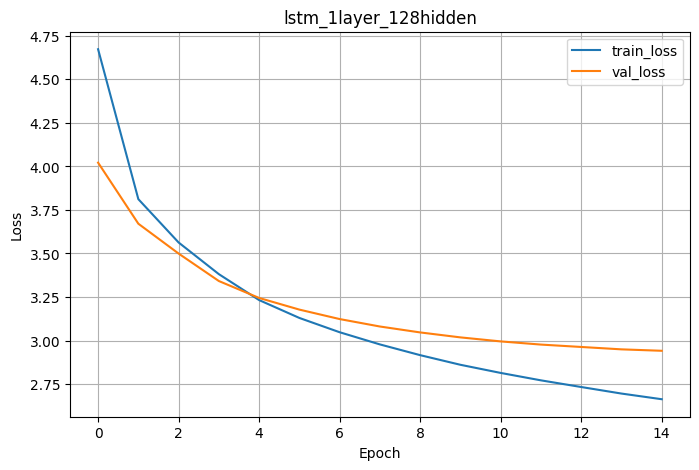

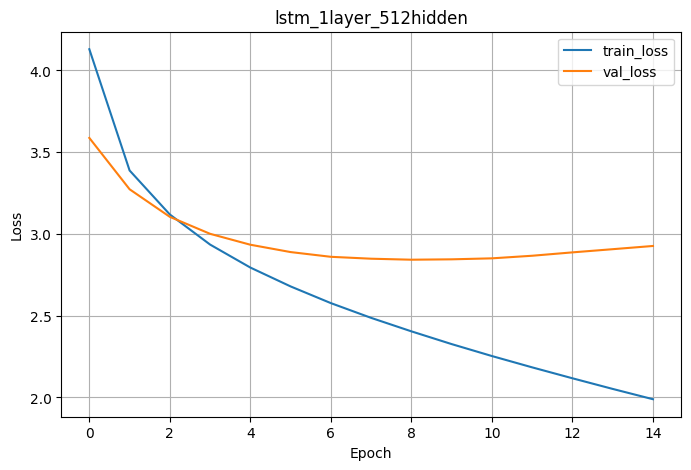

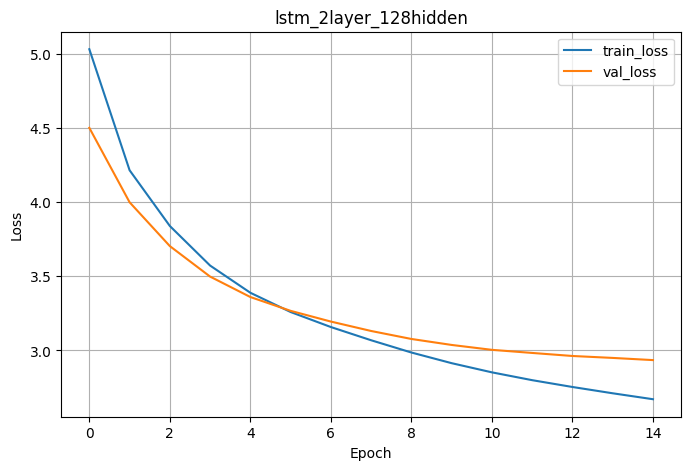

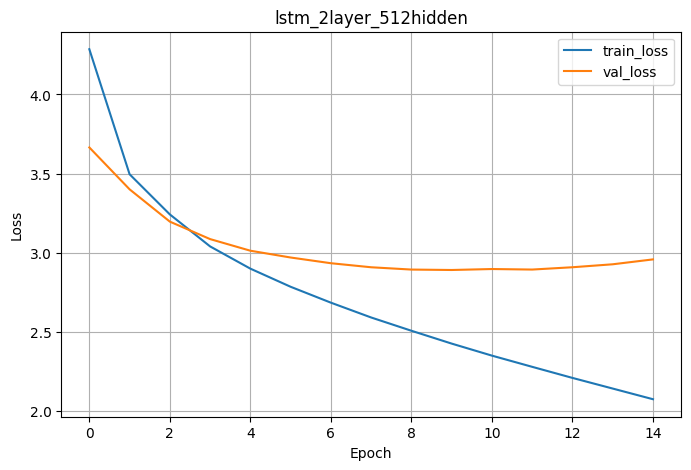

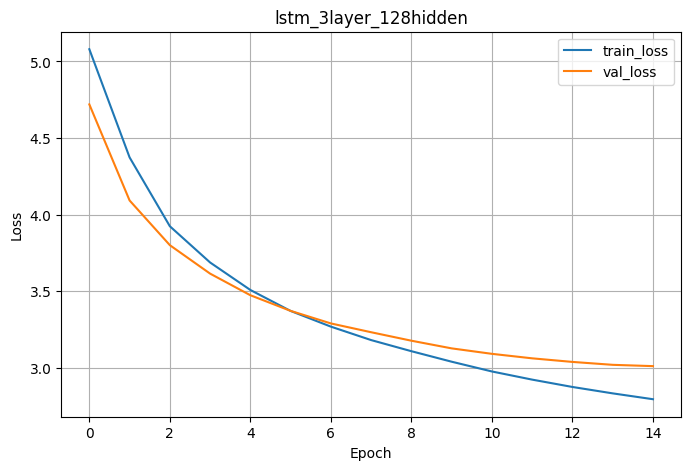

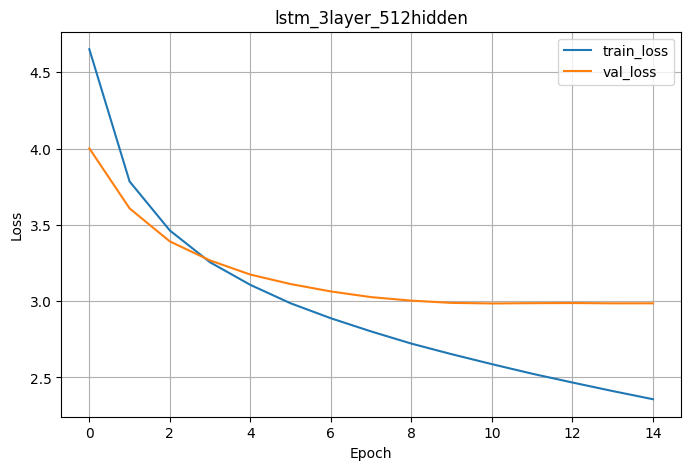

In [33]:
def plot_history(history_dict, title):
    plt.figure(figsize=(8, 5))
    plt.plot(history_dict['loss'], label='train_loss')
    plt.plot(history_dict['val_loss'], label='val_loss')
    plt.title(title)
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    plt.show()

for name, hist in all_histories.items():
    plot_history(hist, name)

## 10. Greedy decoding Keras

In [34]:
idx_to_word_dict = {i: w for i, w in enumerate(idx_to_word)}
word_to_idx_dict = word_to_idx

def ids_to_sentence(ids):
    words = []
    for idx in ids:
        idx = int(idx)
        w = idx_to_word_dict.get(idx, UNK_TOKEN)
        if w in [PAD_TOKEN, START_TOKEN]:
            continue
        if w == END_TOKEN:
            break
        words.append(w)
    return ' '.join(words)

def generate_caption_keras(model, image_feature, max_caption_len=20):
    tokens = [START_ID]

    for _ in range(max_caption_len):
        inp = tokens[-MAX_INPUT_LEN:]
        inp = inp + [PAD_ID] * (MAX_INPUT_LEN - len(inp))
        inp = np.array(inp, dtype=np.int32)[None, :]

        feat = image_feature.astype(np.float32)[None, :]
        probs = model.predict([feat, inp], verbose=0)

        timestep = min(len(tokens) - 1, probs.shape[1] - 1)

        next_prob = probs[0, timestep, :].copy()
        next_prob[PAD_ID] = -1.0
        next_prob[START_ID] = -1.0
        next_prob[UNK_ID] = -1.0

        next_id = int(np.argmax(next_prob))

        if next_id == END_ID:
            break
        
        tokens.append(next_id)

    return ids_to_sentence(tokens[1:])

if 'training_summary' in globals() and len(training_summary) > 0:
    best_quick_row = min(training_summary, key=lambda row: row['best_val_loss'])
    quick_model = tf.keras.models.load_model(
        best_quick_row["model_path"],
        compile=False,
        safe_mode=False
    )
    sample_image = test_df.iloc[0]['image']
    print('Sample image:', sample_image)
    print('Prediction:', generate_caption_keras(quick_model, features[sample_image], max_caption_len=20))
    print('Ground truth:', test_df[test_df['image'] == sample_image]['caption'].tolist())

Sample image: 1003163366_44323f5815.jpg
Prediction: a small dog is jumping over a fence
Ground truth: ['A man lays on a bench while his dog sits by him .', 'A man lays on the bench to which a white dog is also tied .', 'a man sleeping on a bench outside with a white and black dog sitting next to him .', 'A shirtless man lies on a park bench with his dog .', 'man laying on bench holding leash of dog sitting on ground']


## 11. Evaluasi BLEU-4 dan METEOR

In [35]:
from nltk.translate.meteor_score import meteor_score

def get_references_for_image(df, image_name):
    refs = []
    for cap in df[df["image"] == image_name]["clean_caption"]:
        refs.append(cap.split())
    return refs

def compute_meteor(references, hypothesis):
    try:
        return meteor_score(references, hypothesis)
    except Exception:
        return 0.0

def evaluate_caption_model_keras(model, df_eval, max_images=1000, max_caption_len=20):
    eval_images = sorted(df_eval["image"].unique())[:max_images]

    references_all = []
    hypotheses_all = []
    meteor_scores = []

    start = time.time()

    for name in eval_images:
        pred = generate_caption_keras(
            model,
            features[name],
            max_caption_len=max_caption_len
        )

        hyp = pred.split()
        refs = get_references_for_image(df_eval, name)

        references_all.append(refs)
        hypotheses_all.append(hyp)
        meteor_scores.append(compute_meteor(refs, hyp))

    bleu4 = corpus_bleu(
        references_all,
        hypotheses_all,
        weights=(0.25, 0.25, 0.25, 0.25),
        smoothing_function=SmoothingFunction().method4,
    )

    return {
        "BLEU_4": float(bleu4),
        "METEOR": float(np.mean(meteor_scores)),
        "eval_time_sec": time.time() - start,
        "num_images": len(eval_images),
    }


def evaluate_saved_model(row, df_eval, max_images=1000, max_caption_len=20):
    loaded_model = tf.keras.models.load_model(
        row["model_path"],
        compile=False,
        safe_mode=False
    )

    metrics = evaluate_caption_model_keras(
        loaded_model,
        df_eval,
        max_images=max_images,
        max_caption_len=max_caption_len,
    )

    return {**row, **metrics}


eval_rows = []

for row in training_summary:
    print("Evaluating:", row["name"])
    eval_rows.append(
        evaluate_saved_model(
            row,
            test_df,
            max_images=1000,
            max_caption_len=20
        )
    )

eval_df = pd.DataFrame(eval_rows).sort_values(
    ["BLEU_4", "METEOR"],
    ascending=False
)

eval_df.to_csv(RESULT_DIR / "lstm_eval_keras.csv", index=False)
eval_df

Evaluating: lstm_1layer_128hidden


KeyboardInterrupt: 

In [ ]:
# row = next(r for r in training_summary if r['name'] == 'lstm_1layer_512hidden')
# print('Evaluating:', row['name'])
# eval_rows.append(evaluate_saved_model(row, test_df, max_images=1000, max_caption_len=20))
# pd.DataFrame(eval_rows)

Evaluating: lstm_1layer_512hidden


,name,num_layers,hidden_size,train_time_sec,best_val_loss,model_path,BLEU_4,METEOR,eval_time_sec,num_images
0,lstm_1layer_128hidden,1,128,651.681745,1.8478,artifacts_lstm\models\lstm_1layer_128hidden.keras,0.099210,0.340165,1475.325891,1000
1,lstm_1layer_512hidden,1,512,1982.138927,1.7330,artifacts_lstm\models\lstm_1layer_512hidden.keras,0.149591,0.389142,2228.801534,1000


In [ ]:
# row = next(r for r in training_summary if r['name'] == 'lstm_2layer_128hidden')
# print('Evaluating:', row['name'])
# eval_rows.append(evaluate_saved_model(row, test_df, max_images=1000, max_caption_len=20))
# pd.DataFrame(eval_rows)

Evaluating: lstm_2layer_128hidden


,name,num_layers,hidden_size,train_time_sec,best_val_loss,model_path,BLEU_4,METEOR,eval_time_sec,num_images
0,lstm_1layer_128hidden,1,128,651.681745,1.84780,artifacts_lstm\models\lstm_1layer_128hidden.keras,0.099210,0.340165,1475.325891,1000
1,lstm_1layer_512hidden,1,512,1982.138927,1.73300,artifacts_lstm\models\lstm_1layer_512hidden.keras,0.149591,0.389142,2228.801534,1000
2,lstm_2layer_128hidden,2,128,852.290356,1.87384,artifacts_lstm\models\lstm_2layer_128hidden.keras,0.098150,0.356268,2949.341440,1000


In [ ]:
# row = next(r for r in training_summary if r['name'] == 'lstm_2layer_512hidden')
# print('Evaluating:', row['name'])
# eval_rows.append(evaluate_saved_model(row, test_df, max_images=1000, max_caption_len=20))
# pd.DataFrame(eval_rows)

Evaluating: lstm_2layer_512hidden


,name,num_layers,hidden_size,train_time_sec,best_val_loss,model_path,BLEU_4,METEOR,eval_time_sec,num_images
0,lstm_1layer_128hidden,1,128,651.681745,1.847800,artifacts_lstm\models\lstm_1layer_128hidden.keras,0.099210,0.340165,1475.325891,1000
1,lstm_1layer_512hidden,1,512,1982.138927,1.733000,artifacts_lstm\models\lstm_1layer_512hidden.keras,0.149591,0.389142,2228.801534,1000
2,lstm_2layer_128hidden,2,128,852.290356,1.873840,artifacts_lstm\models\lstm_2layer_128hidden.keras,0.098150,0.356268,2949.341440,1000
3,lstm_2layer_512hidden,2,512,3126.798132,1.760609,artifacts_lstm\models\lstm_2layer_512hidden.keras,0.135937,0.385811,2296.215713,1000


In [ ]:
# row = next(r for r in training_summary if r['name'] == 'lstm_3layer_128hidden')
# print('Evaluating:', row['name'])
# eval_rows.append(evaluate_saved_model(row, test_df, max_images=1000, max_caption_len=20))
# pd.DataFrame(eval_rows)

Evaluating: lstm_3layer_128hidden


,name,num_layers,hidden_size,train_time_sec,best_val_loss,model_path,BLEU_4,METEOR,eval_time_sec,num_images
0,lstm_1layer_128hidden,1,128,651.681745,1.847800,artifacts_lstm\models\lstm_1layer_128hidden.keras,0.099210,0.340165,1475.325891,1000
1,lstm_1layer_512hidden,1,512,1982.138927,1.733000,artifacts_lstm\models\lstm_1layer_512hidden.keras,0.149591,0.389142,2228.801534,1000
2,lstm_2layer_128hidden,2,128,852.290356,1.873840,artifacts_lstm\models\lstm_2layer_128hidden.keras,0.098150,0.356268,2949.341440,1000
3,lstm_2layer_512hidden,2,512,3126.798132,1.760609,artifacts_lstm\models\lstm_2layer_512hidden.keras,0.135937,0.385811,2296.215713,1000
4,lstm_3layer_128hidden,3,128,1006.151664,2.037790,artifacts_lstm\models\lstm_3layer_128hidden.keras,0.104928,0.352471,1559.696109,1000


In [ ]:
# row = next(r for r in training_summary if r['name'] == 'lstm_3layer_512hidden')
# print('Evaluating:', row['name'])
# eval_rows.append(evaluate_saved_model(row, test_df, max_images=1000, max_caption_len=20))
# eval_df = pd.DataFrame(eval_rows).sort_values(['BLEU_4', 'METEOR'], ascending=False)
# eval_df.to_csv(RESULT_DIR / 'lstm_eval_keras.csv', index=False)
# eval_df

Evaluating: lstm_3layer_512hidden


,name,num_layers,hidden_size,train_time_sec,best_val_loss,model_path,BLEU_4,METEOR,eval_time_sec,num_images
1,lstm_1layer_512hidden,1,512,1982.138927,1.733000,artifacts_lstm\models\lstm_1layer_512hidden.keras,0.149591,0.389142,2228.801534,1000
3,lstm_2layer_512hidden,2,512,3126.798132,1.760609,artifacts_lstm\models\lstm_2layer_512hidden.keras,0.135937,0.385811,2296.215713,1000
5,lstm_3layer_512hidden,3,512,4618.764656,1.823594,artifacts_lstm\models\lstm_3layer_512hidden.keras,0.129267,0.360328,1784.976198,1000
4,lstm_3layer_128hidden,3,128,1006.151664,2.037790,artifacts_lstm\models\lstm_3layer_128hidden.keras,0.104928,0.352471,1559.696109,1000
0,lstm_1layer_128hidden,1,128,651.681745,1.847800,artifacts_lstm\models\lstm_1layer_128hidden.keras,0.099210,0.340165,1475.325891,1000
2,lstm_2layer_128hidden,2,128,852.290356,1.873840,artifacts_lstm\models\lstm_2layer_128hidden.keras,0.098150,0.356268,2949.341440,1000


## 12. Load bobot Keras ke LSTM from scratch NumPy

In [ ]:
import sys
sys.path.append('.')

from layer import EmbeddingLayer, DenseLayer, LSTMLayer
from model import LSTMFromScratch

def build_lstm_scratch_from_keras_notebook(keras_model, word_to_idx, idx_to_word, max_len=30, num_lstm_layers=1):
    embedding_weights = keras_model.get_layer('embedding').get_weights()[0]
    feature_projection_weights = keras_model.get_layer('feature_projection').get_weights()
    output_weights = keras_model.get_layer('output_dense').get_weights()

    embedding_layer = EmbeddingLayer(embedding_weights)
    feature_projection_layer = DenseLayer(feature_projection_weights, activation=None)

    lstm_layers = []
    for i in range(num_lstm_layers):
        layer_name = 'lstm' if i == 0 else f'lstm_{i}'
        keras_lstm_layer = keras_model.get_layer(layer_name)
        lstm_layers.append(
            LSTMLayer(
                units=keras_lstm_layer.units,
                return_sequences=True,
                weights=keras_lstm_layer.get_weights(),
            )
        )

    output_layer = DenseLayer(output_weights, activation='softmax')

    idx_to_word_for_model = {str(i): w for i, w in enumerate(idx_to_word)}
    return LSTMFromScratch(
        embedding_layer=embedding_layer,
        feature_projection_layer=feature_projection_layer,
        lstm_layers=lstm_layers,
        output_layer=output_layer,
        word_to_idx=word_to_idx,
        idx_to_word=idx_to_word_for_model,
        max_len=max_len,
    )

best_row = eval_df.sort_values(['BLEU_4', 'METEOR'], ascending=False).iloc[0]
best_model_path = best_row['model_path']
best_keras_model = tf.keras.models.load_model(
    best_model_path,
    compile=False,
    safe_mode=False
)

num_layers = int(best_row['num_layers'])
scratch_decoder = build_lstm_scratch_from_keras_notebook(
    best_keras_model,
    word_to_idx=word_to_idx_dict,
    idx_to_word=idx_to_word,
    max_len=30,
    num_lstm_layers=num_layers,
)

print('Scratch decoder berhasil dibuat dari:', best_model_path)

Scratch decoder berhasil dibuat dari: artifacts_lstm\models\lstm_1layer_512hidden.keras


In [ ]:
def generate_caption_scratch(decoder, image_feature, max_caption_len=20):
    old_max_len = decoder.max_len
    decoder.max_len = max_caption_len
    try:
        return decoder.greedy_decode(image_feature.astype(np.float32))
    finally:
        decoder.max_len = old_max_len

sample_image = test_df.iloc[0]['image']
print('Keras  :', generate_caption_keras(best_keras_model, features[sample_image], max_caption_len=20))
print('Scratch:', generate_caption_scratch(scratch_decoder, features[sample_image], max_caption_len=20))
print('Ground truth:', test_df[test_df['image'] == sample_image]['caption'].tolist())

Keras  : a man and a woman are sitting on a bench
Scratch: a man and a woman are sitting on a bench
Ground truth: ['A man lays on a bench while his dog sits by him .', 'A man lays on the bench to which a white dog is also tied .', 'a man sleeping on a bench outside with a white and black dog sitting next to him .', 'A shirtless man lies on a park bench with his dog .', 'man laying on bench holding leash of dog sitting on ground']


d:\Nayla\Tubes2_IF3270_Kelompok9\src\lstm\layer.py:52: RuntimeWarning: overflow encountered in exp
  return 1.0 / (1.0 + np.exp(-np.clip(x, -500, 500)))


## 13. Evaluasi Scratch

In [ ]:
def evaluate_caption_model_scratch(decoder, df_eval, max_images=1000, max_caption_len=20):
    eval_images = sorted(df_eval['image'].unique())[:max_images]

    references_all = []
    hypotheses_all = []
    meteor_scores = []

    start = time.time()
    for name in eval_images:
        pred = generate_caption_scratch(decoder, features[name], max_caption_len=max_caption_len)
        hyp = pred.split()
        refs = get_references_for_image(df_eval, name)

        references_all.append(refs)
        hypotheses_all.append(hyp)

        meteor_scores.append(compute_meteor(refs, hyp))

    if HAS_NLTK:
        bleu4 = corpus_bleu(
            references_all,
            hypotheses_all,
            weights=(0.25, 0.25, 0.25, 0.25),
            smoothing_function=SmoothingFunction().method4,
        )
    else:
        bleu4 = np.nan

    return {
        'BLEU_4': float(bleu4),
        'METEOR': float(np.mean(meteor_scores)),
        'eval_time_sec': time.time() - start,
        'num_images': len(eval_images),
    }

scratch_metrics = evaluate_caption_model_scratch(
    scratch_decoder,
    test_df,
    max_images=1000,
    max_caption_len=20,
)
scratch_metrics_df = pd.DataFrame([scratch_metrics])
scratch_metrics_df.to_csv(RESULT_DIR / 'lstm_eval_scratch.csv', index=False)

best_row_for_comparison = eval_df.sort_values(['BLEU_4', 'METEOR'], ascending=False).iloc[0]
keras_metrics = {
    'BLEU_4': float(best_row_for_comparison['BLEU_4']),
    'METEOR': float(best_row_for_comparison['METEOR']),
    'eval_time_sec': float(best_row_for_comparison['eval_time_sec']),
    'num_images': int(best_row_for_comparison['num_images']),
}

comparison_df = pd.DataFrame([
    {'implementation': 'Keras', **keras_metrics},
    {'implementation': 'Scratch', **scratch_metrics},
])
comparison_df.to_csv(RESULT_DIR / 'lstm_keras_vs_scratch.csv', index=False)
comparison_df

d:\Nayla\Tubes2_IF3270_Kelompok9\src\lstm\layer.py:52: RuntimeWarning: overflow encountered in exp
  return 1.0 / (1.0 + np.exp(-np.clip(x, -500, 500)))
d:\Nayla\Tubes2_IF3270_Kelompok9\src\lstm\layer.py:52: RuntimeWarning: overflow encountered in exp
  return 1.0 / (1.0 + np.exp(-np.clip(x, -500, 500)))
d:\Nayla\Tubes2_IF3270_Kelompok9\src\lstm\layer.py:52: RuntimeWarning: overflow encountered in exp
  return 1.0 / (1.0 + np.exp(-np.clip(x, -500, 500)))
d:\Nayla\Tubes2_IF3270_Kelompok9\src\lstm\layer.py:52: RuntimeWarning: overflow encountered in exp
  return 1.0 / (1.0 + np.exp(-np.clip(x, -500, 500)))
d:\Nayla\Tubes2_IF3270_Kelompok9\src\lstm\layer.py:52: RuntimeWarning: overflow encountered in exp
  return 1.0 / (1.0 + np.exp(-np.clip(x, -500, 500)))
d:\Nayla\Tubes2_IF3270_Kelompok9\src\lstm\layer.py:52: RuntimeWarning: overflow encountered in exp
  return 1.0 / (1.0 + np.exp(-np.clip(x, -500, 500)))
d:\Nayla\Tubes2_IF3270_Kelompok9\src\lstm\layer.py:52: RuntimeWarning: overflow en

,implementation,BLEU_4,METEOR,eval_time_sec,num_images
0,Keras,0.149591,0.389142,2228.801534,1000
1,Scratch,0.149591,0.389142,134.516548,1000


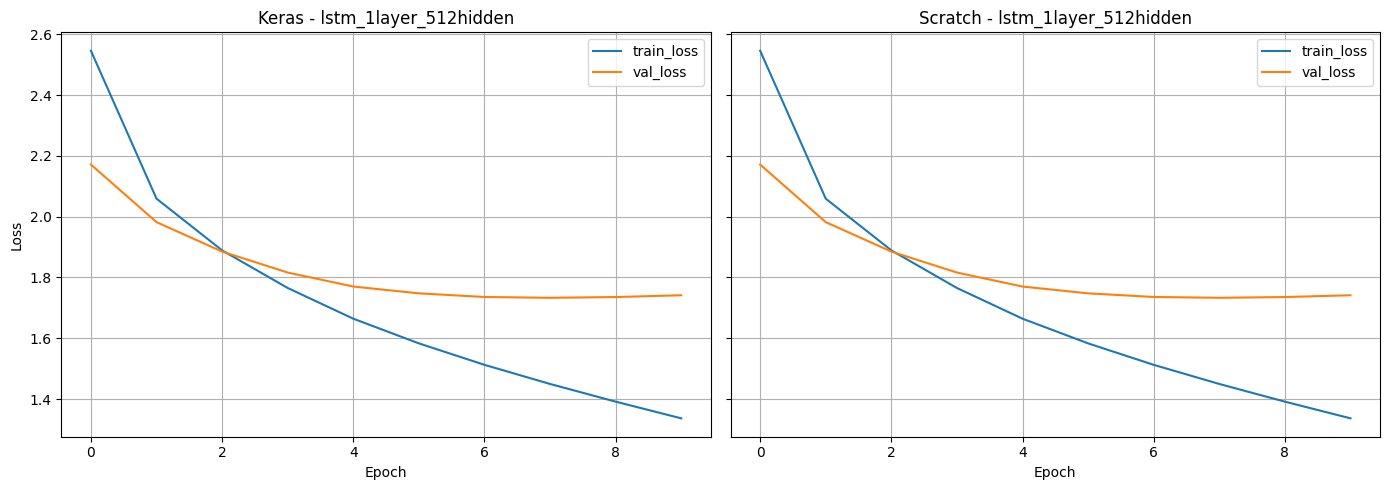

In [ ]:
history_data = None
summary_csv = RESULT_DIR / 'lstm_training_summary.csv'
if summary_csv.exists():
    summary_df = pd.read_csv(summary_csv)
    if len(summary_df) > 0:
        history_data = summary_df.sort_values('best_val_loss').iloc[0]

if history_data is None:
    raise RuntimeError(
        "No training history found"
    )

model_name = str(history_data['name'])
history_path = RESULT_DIR / f"{model_name}_history.json"
with open(history_path, 'r', encoding='utf-8') as f:
    history_dict = json.load(f)
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

axes[0].plot(history_dict['loss'], label='train_loss')
axes[0].plot(history_dict['val_loss'], label='val_loss')
axes[0].set_title(f"Keras - {model_name}")
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(history_dict['loss'], label='train_loss')
axes[1].plot(history_dict['val_loss'], label='val_loss')
axes[1].set_title(f"Scratch - {model_name}")
axes[1].set_xlabel('Epoch')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

## 14. Pengaruh panjang maksimum caption

In [ ]:
max_len_rows = []
for max_len in [10, 20, 30]:
    print('max_caption_len:', max_len)
    metrics = evaluate_caption_model_scratch(
        scratch_decoder,
        test_df,
        max_images=1000,
        max_caption_len=max_len,
    )
    max_len_rows.append({'max_caption_len': max_len, **metrics})

max_len_df = pd.DataFrame(max_len_rows)
max_len_df.to_csv(RESULT_DIR / 'lstm_max_caption_len.csv', index=False)
max_len_df

max_caption_len: 10


d:\Nayla\Tubes2_IF3270_Kelompok9\src\lstm\layer.py:52: RuntimeWarning: overflow encountered in exp
  return 1.0 / (1.0 + np.exp(-np.clip(x, -500, 500)))
d:\Nayla\Tubes2_IF3270_Kelompok9\src\lstm\layer.py:52: RuntimeWarning: overflow encountered in exp
  return 1.0 / (1.0 + np.exp(-np.clip(x, -500, 500)))
d:\Nayla\Tubes2_IF3270_Kelompok9\src\lstm\layer.py:52: RuntimeWarning: overflow encountered in exp
  return 1.0 / (1.0 + np.exp(-np.clip(x, -500, 500)))
d:\Nayla\Tubes2_IF3270_Kelompok9\src\lstm\layer.py:52: RuntimeWarning: overflow encountered in exp
  return 1.0 / (1.0 + np.exp(-np.clip(x, -500, 500)))
d:\Nayla\Tubes2_IF3270_Kelompok9\src\lstm\layer.py:52: RuntimeWarning: overflow encountered in exp
  return 1.0 / (1.0 + np.exp(-np.clip(x, -500, 500)))
d:\Nayla\Tubes2_IF3270_Kelompok9\src\lstm\layer.py:52: RuntimeWarning: overflow encountered in exp
  return 1.0 / (1.0 + np.exp(-np.clip(x, -500, 500)))
d:\Nayla\Tubes2_IF3270_Kelompok9\src\lstm\layer.py:52: RuntimeWarning: overflow en

max_caption_len: 20


d:\Nayla\Tubes2_IF3270_Kelompok9\src\lstm\layer.py:52: RuntimeWarning: overflow encountered in exp
  return 1.0 / (1.0 + np.exp(-np.clip(x, -500, 500)))
d:\Nayla\Tubes2_IF3270_Kelompok9\src\lstm\layer.py:52: RuntimeWarning: overflow encountered in exp
  return 1.0 / (1.0 + np.exp(-np.clip(x, -500, 500)))
d:\Nayla\Tubes2_IF3270_Kelompok9\src\lstm\layer.py:52: RuntimeWarning: overflow encountered in exp
  return 1.0 / (1.0 + np.exp(-np.clip(x, -500, 500)))
d:\Nayla\Tubes2_IF3270_Kelompok9\src\lstm\layer.py:52: RuntimeWarning: overflow encountered in exp
  return 1.0 / (1.0 + np.exp(-np.clip(x, -500, 500)))
d:\Nayla\Tubes2_IF3270_Kelompok9\src\lstm\layer.py:52: RuntimeWarning: overflow encountered in exp
  return 1.0 / (1.0 + np.exp(-np.clip(x, -500, 500)))
d:\Nayla\Tubes2_IF3270_Kelompok9\src\lstm\layer.py:52: RuntimeWarning: overflow encountered in exp
  return 1.0 / (1.0 + np.exp(-np.clip(x, -500, 500)))
d:\Nayla\Tubes2_IF3270_Kelompok9\src\lstm\layer.py:52: RuntimeWarning: overflow en

max_caption_len: 30


d:\Nayla\Tubes2_IF3270_Kelompok9\src\lstm\layer.py:52: RuntimeWarning: overflow encountered in exp
  return 1.0 / (1.0 + np.exp(-np.clip(x, -500, 500)))
d:\Nayla\Tubes2_IF3270_Kelompok9\src\lstm\layer.py:52: RuntimeWarning: overflow encountered in exp
  return 1.0 / (1.0 + np.exp(-np.clip(x, -500, 500)))
d:\Nayla\Tubes2_IF3270_Kelompok9\src\lstm\layer.py:52: RuntimeWarning: overflow encountered in exp
  return 1.0 / (1.0 + np.exp(-np.clip(x, -500, 500)))
d:\Nayla\Tubes2_IF3270_Kelompok9\src\lstm\layer.py:52: RuntimeWarning: overflow encountered in exp
  return 1.0 / (1.0 + np.exp(-np.clip(x, -500, 500)))
d:\Nayla\Tubes2_IF3270_Kelompok9\src\lstm\layer.py:52: RuntimeWarning: overflow encountered in exp
  return 1.0 / (1.0 + np.exp(-np.clip(x, -500, 500)))
d:\Nayla\Tubes2_IF3270_Kelompok9\src\lstm\layer.py:52: RuntimeWarning: overflow encountered in exp
  return 1.0 / (1.0 + np.exp(-np.clip(x, -500, 500)))
d:\Nayla\Tubes2_IF3270_Kelompok9\src\lstm\layer.py:52: RuntimeWarning: overflow en

,max_caption_len,BLEU_4,METEOR,eval_time_sec,num_images
0,10,0.158215,0.378821,95.203928,1000
1,20,0.149591,0.389142,126.392479,1000
2,30,0.149591,0.389142,120.190144,1000


## 15. Qualitative analysis 10 contoh gambar

In [ ]:
def sentence_bleu4(refs, hyp):
    if not HAS_NLTK:
        return np.nan
    return sentence_bleu(
        refs,
        hyp,
        weights=(0.25, 0.25, 0.25, 0.25),
        smoothing_function=SmoothingFunction().method4,
    )

qual_rows = []
for name in sorted(test_df['image'].unique())[:200]:
    pred = generate_caption_scratch(scratch_decoder, features[name], max_caption_len=20)
    hyp = pred.split()
    refs = get_references_for_image(test_df, name)

    qual_rows.append({
        'image': name,
        'pred_caption_lstm': pred,
        'ground_truth': ' | '.join(test_df[test_df['image'] == name]['caption'].tolist()),
        'sentence_bleu4': sentence_bleu4(refs, hyp),
    })

qual_df = pd.DataFrame(qual_rows).sort_values('sentence_bleu4', ascending=False)

# Ambil contoh tinggi, sedang, rendah.
high = qual_df.head(4)
mid = qual_df.iloc[max(len(qual_df)//2 - 2, 0): max(len(qual_df)//2 + 2, 0)]
low = qual_df.tail(4)
qual_sample_df = pd.concat([high, mid, low]).drop_duplicates('image').head(10)

qual_df.to_csv(RESULT_DIR / 'lstm_qualitative_all.csv', index=False)
qual_sample_df.to_csv(RESULT_DIR / 'lstm_qualitative_sample.csv', index=False)
qual_sample_df

d:\Nayla\Tubes2_IF3270_Kelompok9\src\lstm\layer.py:52: RuntimeWarning: overflow encountered in exp
  return 1.0 / (1.0 + np.exp(-np.clip(x, -500, 500)))
d:\Nayla\Tubes2_IF3270_Kelompok9\src\lstm\layer.py:52: RuntimeWarning: overflow encountered in exp
  return 1.0 / (1.0 + np.exp(-np.clip(x, -500, 500)))
d:\Nayla\Tubes2_IF3270_Kelompok9\src\lstm\layer.py:52: RuntimeWarning: overflow encountered in exp
  return 1.0 / (1.0 + np.exp(-np.clip(x, -500, 500)))
d:\Nayla\Tubes2_IF3270_Kelompok9\src\lstm\layer.py:52: RuntimeWarning: overflow encountered in exp
  return 1.0 / (1.0 + np.exp(-np.clip(x, -500, 500)))
d:\Nayla\Tubes2_IF3270_Kelompok9\src\lstm\layer.py:52: RuntimeWarning: overflow encountered in exp
  return 1.0 / (1.0 + np.exp(-np.clip(x, -500, 500)))
d:\Nayla\Tubes2_IF3270_Kelompok9\src\lstm\layer.py:52: RuntimeWarning: overflow encountered in exp
  return 1.0 / (1.0 + np.exp(-np.clip(x, -500, 500)))
d:\Nayla\Tubes2_IF3270_Kelompok9\src\lstm\layer.py:52: RuntimeWarning: overflow en

,image,pred_caption_lstm,ground_truth,sentence_bleu4
107,2056930414_d2b0f1395a.jpg,a little boy is playing with a toy car,A child plays a red toy guitar and sings into ...,0.772551
162,2260560631_09093be4c6.jpg,a dog is running through a grassy field,A dirty dogs runs through the woods . | A dog ...,0.740083
130,2135502491_a15c6b5eae.jpg,a brown and white dog is running through a gra...,A beautiful brown and white St Bernard running...,0.590047
20,1236951314_0308dc4138.jpg,a boy in a blue shirt is jumping into a swimmi...,A boy in a wetsuit jumps into a pool with a ba...,0.521695
43,1396064003_3fd949c9dd.jpg,a man in a blue shirt is surfing,A man hangs upside in the air over the water ....,0.084704
21,1244140539_da4804d828.jpg,a dog is running through a grassy field,A black and brown dog is laying on a white sha...,0.084704
169,2287887341_663bfa15af.jpg,a dog is running through a grassy field,A dog pants inside a car | A dog sits in a car...,0.084704
101,201682811_105241dee3.jpg,two children are playing in a fountain,Two men are approaching a gold colored statue ...,0.084471
31,1299459550_1fd5594fa2.jpg,a little girl in a pink bathing suit is jumpin...,A boy in swimming trunks . | A toddler in blue...,0.024870
168,2286823363_7d554ea740.jpg,a man in a blue shirt is jumping over a blue a...,A little boy jumping from one chair to another...,0.024870


Image: 2056930414_d2b0f1395a.jpg
BLEU-4: 0.7725505949016372
LSTM prediction: a little boy is playing with a toy car
Ground truth: A child plays a red toy guitar and sings into multicolored plastic microphone . | A little boy is playing with a toy guitar and microphone . | A little boy plays a toy guitar while singing into a toy microphone . | A little boy with toy microphone and guitar pretends to play music . | The child has a small red guitar and toy microphone .


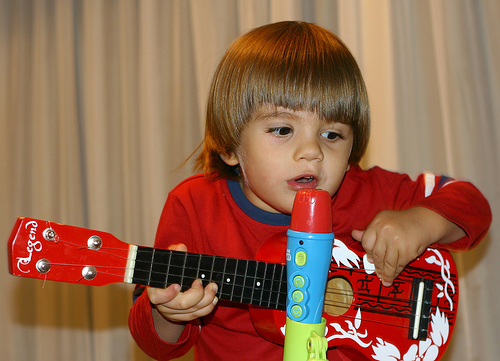

Image: 2260560631_09093be4c6.jpg
BLEU-4: 0.7400828044922853
LSTM prediction: a dog is running through a grassy field
Ground truth: A dirty dogs runs through the woods . | A dog carries a stick through the woods . | A dog jumping over a stick in the yard . | A dog jumps over a stick in a forest . | The furry dog is running through a grassy wooded area .


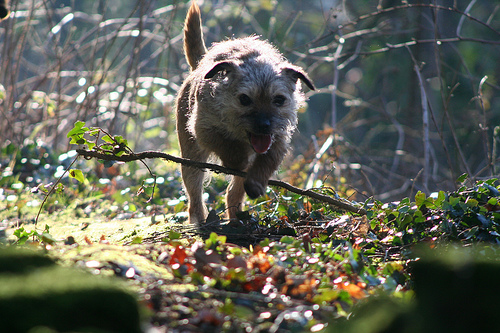

Image: 2135502491_a15c6b5eae.jpg
BLEU-4: 0.5900468726392808
LSTM prediction: a brown and white dog is running through a grassy area
Ground truth: A beautiful brown and white St Bernard running in the snow | A St Bernard lunges through the snow . | Large St Bernard dog wearing red collar galloping through the snow . | St Bernard dog running in the snowy field . | The large brown and white dog is running through the snow .


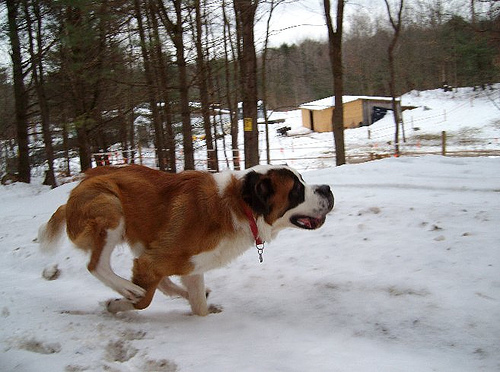

Image: 1236951314_0308dc4138.jpg
BLEU-4: 0.5216948600244291
LSTM prediction: a boy in a blue shirt is jumping into a swimming pool
Ground truth: A boy in a wetsuit jumps into a pool with a bald man . | A boy with goggles jumping into a pool containing a man . | A child is jumping into a pool while a man is watching the child | A swimming person is watching a child jump into a pool with blue water . | A young boy jumps in a swimming pool towards a bald man in the water .


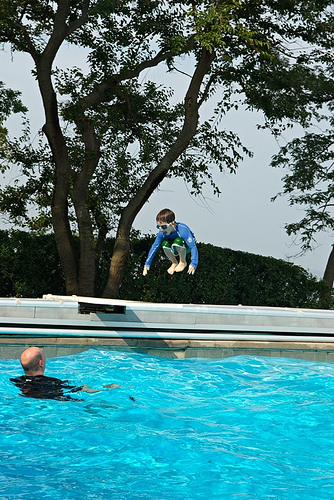

Image: 1396064003_3fd949c9dd.jpg
BLEU-4: 0.0847039252508118
LSTM prediction: a man in a blue shirt is surfing
Ground truth: A man hangs upside in the air over the water . | an upside down man doing a flip on a waterski board | A person did a side flip while water boarding . | A person upside down on a water board . | A wakeboarder performs a flip while being towed at high speed .


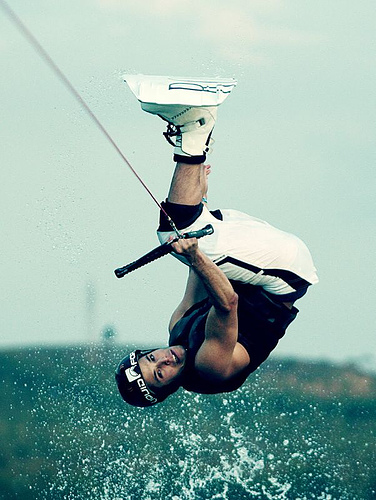

Image: 1244140539_da4804d828.jpg
BLEU-4: 0.0847039252508118
LSTM prediction: a dog is running through a grassy field
Ground truth: A black and brown dog is laying on a white shaggy carpet . | A brown and black dog is laying on a shaggy rug . | a small brown and black dog lying down in a furry rug . | A small dog is sitting on white carpet . | A small dog shakes its head on a white shag carpet .


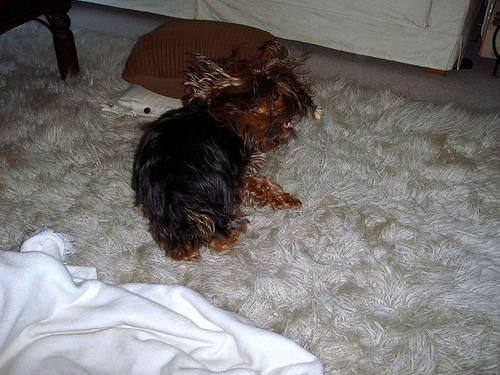

Image: 2287887341_663bfa15af.jpg
BLEU-4: 0.0847039252508118
LSTM prediction: a dog is running through a grassy field
Ground truth: A dog pants inside a car | A dog sits in a car with its tongue sticking out . | A dog wearing a blue leash rides in a car . | A light colored dog with blue leash attached is sitting in a vehicle . | The dog waits patiently in the car for its owner .


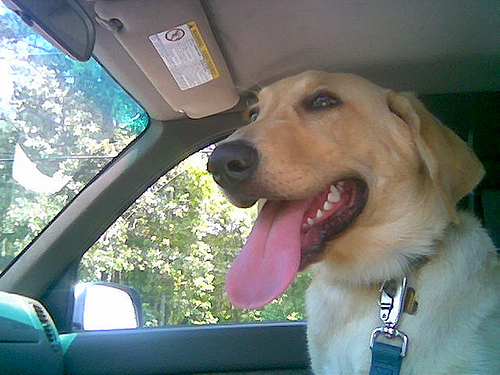

Image: 201682811_105241dee3.jpg
BLEU-4: 0.08447087641106643
LSTM prediction: two children are playing in a fountain
Ground truth: Two men are approaching a gold colored statue of Gandhi . | Two men are standing in a street , one appears to be throwing something . | Two people look up towards a gold statue . | Two people stand and gaze at a golden statue . | Two young men play outside near a golden statue of Ghandi .


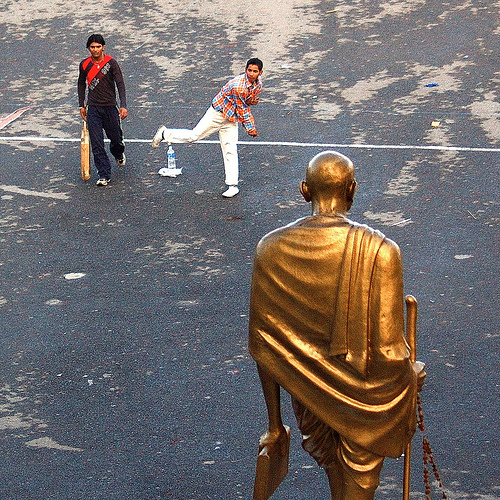

Image: 1299459550_1fd5594fa2.jpg
BLEU-4: 0.024869542143125947
LSTM prediction: a little girl in a pink bathing suit is jumping into a swimming pool
Ground truth: A boy in swimming trunks . | A toddler in blue shorts is laying face down on the wet ground . | A young boy laying face down in water . | Boy in shorts , face down in shallow , reflective water . | The boy in swim trunks is laying face down on a watery pavement .


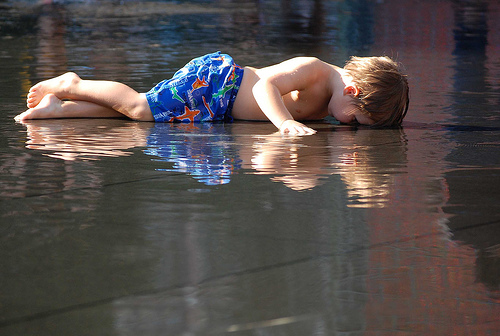

Image: 2286823363_7d554ea740.jpg
BLEU-4: 0.024869542143125947
LSTM prediction: a man in a blue shirt is jumping over a blue and white pole
Ground truth: A little boy jumping from one chair to another . | A young boy jumps from one black chair to another . | A young boy is leaping from one chair to another . | A young boy jumping from one chair to another in his house | A young boy leaps from chair to chair .


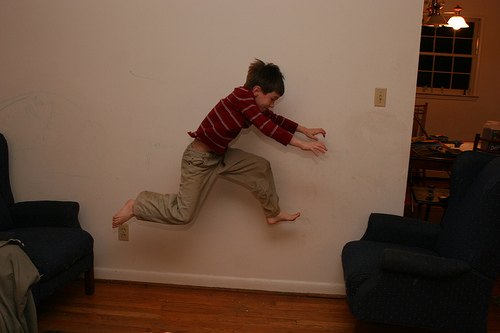

In [ ]:
from IPython.display import display, Image as IPImage

for _, row in qual_sample_df.iterrows():
    print('=' * 80)
    print('Image:', row['image'])
    print('BLEU-4:', row['sentence_bleu4'])
    print('LSTM prediction:', row['pred_caption_lstm'])
    print('Ground truth:', row['ground_truth'])
    display(IPImage(filename=str(IMAGE_DIR / row['image']), width=300))